# **1. Perkenalan Dataset**

Notebook ini menggunakan **Breast Cancer Wisconsin Diagnostic Dataset** sebagai dataset pelatihan untuk eksperimen Machine Learning.

- Sumber dataset: `sklearn.datasets.load_breast_cancer`, lalu disimpan sebagai CSV raw.
- Tipe masalah: klasifikasi biner.
- Target: `diagnosis`.
- Label target: `0` untuk malignant dan `1` untuk benign.

Tujuan eksperimen adalah memahami karakteristik dataset, melakukan EDA, dan membangun proses preprocessing yang konsisten sebelum dibuat otomatisasinya pada file Python.

# **2. Import Library**

Pada tahap ini, library yang digunakan mencakup pandas dan numpy untuk manipulasi data, matplotlib/seaborn untuk EDA, serta scikit-learn untuk splitting dan scaling.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42

# **3. Memuat Dataset**

Pada tahap ini dataset raw dimuat dari folder `breast_cancer_raw`. Dataset ini belum melalui preprocessing sehingga cocok digunakan untuk eksplorasi awal.

In [2]:
cwd = Path.cwd()
if (cwd / "breast_cancer_raw").exists():
    PROJECT_DIR = cwd
elif (cwd.parent / "breast_cancer_raw").exists():
    PROJECT_DIR = cwd.parent
else:
    PROJECT_DIR = Path("..").resolve()

RAW_DATA_PATH = PROJECT_DIR / "breast_cancer_raw" / "breast_cancer_raw.csv"
raw_df = pd.read_csv(RAW_DATA_PATH)

print(f"Path dataset: {RAW_DATA_PATH}")
print(f"Shape dataset: {raw_df.shape}")
raw_df.head()

Path dataset: C:\Users\khoir\Documents\Codex\2026-05-22\new-chat-4\Eksperimen_SML_Khoir\breast_cancer_raw\breast_cancer_raw.csv
Shape dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# **4. Exploratory Data Analysis (EDA)**

EDA dilakukan untuk memahami ukuran dataset, tipe data, missing value, duplikasi, distribusi target, ringkasan statistik, dan korelasi fitur terhadap target.

In [3]:
print("Informasi kolom dan tipe data:")
raw_df.info()

eda_summary = pd.DataFrame({
    "missing_values": raw_df.isna().sum(),
    "missing_percentage": (raw_df.isna().mean() * 100).round(2),
    "unique_values": raw_df.nunique(),
    "dtype": raw_df.dtypes.astype(str),
})

print(f"Jumlah duplikasi: {raw_df.duplicated().sum()}")
display(eda_summary.head(10))
display(raw_df.describe().T.head(10))

Informasi kolom dan tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smooth

,missing_values,missing_percentage,unique_values,dtype
mean radius,0,0.0,456,float64
mean texture,0,0.0,479,float64
mean perimeter,0,0.0,522,float64
mean area,0,0.0,539,float64
mean smoothness,0,0.0,474,float64
mean compactness,0,0.0,537,float64
mean concavity,0,0.0,537,float64
mean concave points,0,0.0,542,float64
mean symmetry,0,0.0,432,float64
mean fractal dimension,0,0.0,499,float64


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


Distribusi target diagnosis:
diagnosis
0    212
1    357
Name: count, dtype: int64


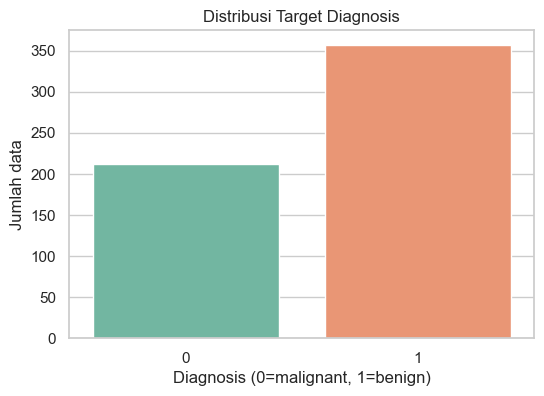

In [4]:
target_distribution = raw_df["diagnosis"].value_counts().sort_index()
print("Distribusi target diagnosis:")
print(target_distribution)

plt.figure(figsize=(6, 4))
sns.countplot(data=raw_df, x="diagnosis", hue="diagnosis", palette="Set2", legend=False)
plt.title("Distribusi Target Diagnosis")
plt.xlabel("Diagnosis (0=malignant, 1=benign)")
plt.ylabel("Jumlah data")
plt.show()

,correlation_with_diagnosis
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


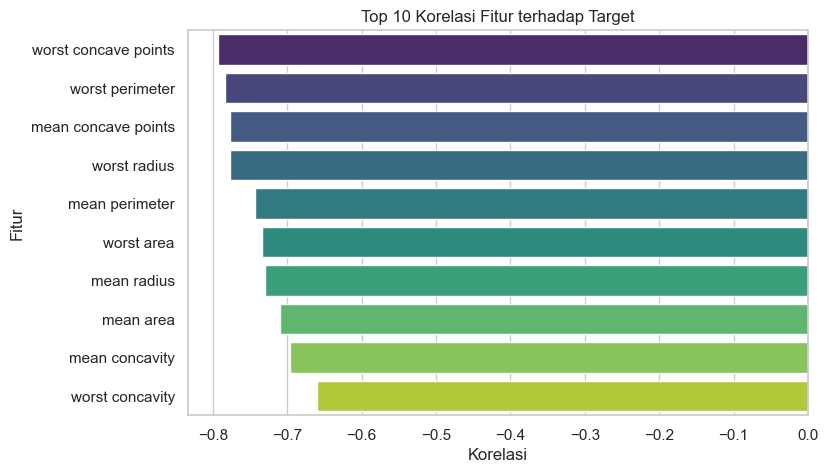

In [5]:
correlation_with_target = (
    raw_df.corr(numeric_only=True)["diagnosis"]
    .drop("diagnosis")
    .sort_values(key=lambda series: series.abs(), ascending=False)
)

top_corr_features = correlation_with_target.head(10)
display(top_corr_features.to_frame(name="correlation_with_diagnosis"))

plt.figure(figsize=(8, 5))
sns.barplot(x=top_corr_features.values, y=top_corr_features.index, hue=top_corr_features.index, palette="viridis", legend=False)
plt.title("Top 10 Korelasi Fitur terhadap Target")
plt.xlabel("Korelasi")
plt.ylabel("Fitur")
plt.show()

# **5. Data Preprocessing**

Tahapan preprocessing manual pada notebook ini sama dengan file otomatisasi:

1. Normalisasi nama kolom.
2. Menghapus duplikasi.
3. Memastikan seluruh fitur numerik.
4. Menghapus missing value.
5. Split train/test secara stratified.
6. Melakukan standardisasi fitur dengan `StandardScaler` yang hanya fit pada train split.
7. Menyimpan dataset siap latih dan metadata preprocessing.

In [6]:
TARGET_COLUMN = "diagnosis"
PROCESSED_DIR = PROJECT_DIR / "preprocessing" / "breast_cancer_preprocessing"
PROCESSED_PATH = PROCESSED_DIR / "breast_cancer_processed.csv"
METADATA_PATH = PROCESSED_DIR / "preprocessing_metadata.json"


def normalize_column_names(dataframe: pd.DataFrame) -> pd.DataFrame:
    dataframe = dataframe.copy()
    dataframe.columns = (
        dataframe.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
    )
    return dataframe


cleaned_df = normalize_column_names(raw_df)
cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

feature_columns = [column for column in cleaned_df.columns if column != TARGET_COLUMN]
cleaned_df[feature_columns] = cleaned_df[feature_columns].apply(pd.to_numeric, errors="coerce")
cleaned_df[TARGET_COLUMN] = pd.to_numeric(cleaned_df[TARGET_COLUMN], errors="coerce")
cleaned_df = cleaned_df.dropna().reset_index(drop=True)
cleaned_df[TARGET_COLUMN] = cleaned_df[TARGET_COLUMN].astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    cleaned_df[feature_columns],
    cleaned_df[TARGET_COLUMN],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=cleaned_df[TARGET_COLUMN],
)

scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=feature_columns, index=x_train.index)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=feature_columns, index=x_test.index)

train_processed = x_train_scaled.copy()
train_processed[TARGET_COLUMN] = y_train
train_processed["split"] = "train"

test_processed = x_test_scaled.copy()
test_processed[TARGET_COLUMN] = y_test
test_processed["split"] = "test"

processed_df = pd.concat([train_processed, test_processed], axis=0).sort_index().reset_index(drop=True)

metadata = {
    "target_column": TARGET_COLUMN,
    "feature_columns": feature_columns,
    "random_state": RANDOM_STATE,
    "train_rows": int((processed_df["split"] == "train").sum()),
    "test_rows": int((processed_df["split"] == "test").sum()),
    "total_rows": int(processed_df.shape[0]),
    "total_features": len(feature_columns),
    "scaler": "StandardScaler fitted on train split only",
}

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
processed_df.to_csv(PROCESSED_PATH, index=False)
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Dataset hasil preprocessing: {PROCESSED_PATH}")
print(f"Metadata preprocessing: {METADATA_PATH}")
print(f"Shape hasil preprocessing: {processed_df.shape}")
processed_df.head()

Dataset hasil preprocessing: C:\Users\khoir\Documents\Codex\2026-05-22\new-chat-4\Eksperimen_SML_Khoir\preprocessing\breast_cancer_preprocessing\breast_cancer_processed.csv
Metadata preprocessing: C:\Users\khoir\Documents\Codex\2026-05-22\new-chat-4\Eksperimen_SML_Khoir\preprocessing\breast_cancer_preprocessing\preprocessing_metadata.json
Shape hasil preprocessing: (569, 32)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis,split
0,1.122229,-2.015105,1.295154,1.022909,1.653850,3.249569,2.582834,2.539907,2.185244,2.221928,2.601676,-0.549014,2.925195,2.736426,-0.218607,1.274069,0.654948,0.668049,1.056763,0.862679,1.931418,-1.337482,2.351571,2.082082,1.326105,2.575175,2.018190,2.270941,2.621624,1.901043,0,train
1,1.860314,-0.335730,1.713848,1.966126,-0.850071,-0.471896,-0.028085,0.561344,0.020753,-0.859923,0.540230,-0.849245,0.291913,0.835056,-0.593459,-0.675360,-0.431502,0.274912,-0.786913,-0.095527,1.849568,-0.359774,1.573491,1.968018,-0.378636,-0.424082,-0.162162,1.080724,-0.245770,0.276024,0,test
2,1.608564,0.455099,1.593629,1.609155,0.999230,1.048039,1.325136,2.046102,0.937185,-0.395688,1.295658,-0.756408,0.894053,1.313275,-0.298111,0.787254,0.178369,1.417714,0.196610,0.278609,1.551547,-0.018862,1.383495,1.520812,0.535887,1.065528,0.805853,1.935162,1.091108,0.197710,0,train
3,-0.757313,0.257391,-0.579430,-0.761659,3.446616,3.367408,1.863974,1.462281,2.819971,4.840942,0.361185,-0.109879,0.315755,-0.287980,0.647000,2.658619,0.744016,1.113710,4.437978,1.948357,-0.265957,0.137121,-0.233885,-0.545566,3.439274,3.831858,1.902288,2.152519,5.777151,4.843262,0,train
4,1.780212,-1.115196,1.805048,1.881962,0.307416,0.541144,1.332483,1.439134,0.010055,-0.557891,1.339017,-0.766217,1.326761,1.323103,1.406920,-0.050307,0.752366,1.142359,-0.367688,0.474499,1.335378,-1.443614,1.374448,1.278199,0.225127,-0.308871,0.572194,0.728456,-0.843724,-0.389646,0,train


In [7]:
print("Distribusi split:")
print(processed_df["split"].value_counts())

print("Distribusi target per split:")
display(pd.crosstab(processed_df["split"], processed_df[TARGET_COLUMN], normalize="index").round(3))

print("Rata-rata fitur train setelah scaling, mendekati 0:")
display(processed_df.loc[processed_df["split"] == "train", feature_columns].mean().head().round(6))

Distribusi split:
split
train    455
test     114
Name: count, dtype: int64
Distribusi target per split:


diagnosis,0,1
split,,
test,0.368,0.632
train,0.374,0.626


Rata-rata fitur train setelah scaling, mendekati 0:


mean_radius       -0.0
mean_texture       0.0
mean_perimeter    -0.0
mean_area         -0.0
mean_smoothness    0.0
dtype: float64